## 1. Import thư viện

In [1]:
import pandas as pd
import numpy as np
import json
import joblib
import warnings
from pathlib import Path
from tqdm import tqdm

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
import seaborn as sns

# Luật kết hợp
from mlxtend.frequent_patterns import fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder

# Hệ thống Gợi ý
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings('ignore')
tqdm.pandas()

ROOT_DIR = Path('..').resolve()
PROCESSED_DIR = ROOT_DIR / 'datas' / 'processed'
MODELS_DIR = ROOT_DIR / 'datas' / 'models'
REC_DIR = ROOT_DIR / 'datas' / 'recommend_dataset'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

print('✅ Thư viện đã import thành công')

✅ Thư viện đã import thành công


## 2. Tải dữ liệu

In [2]:
df = pd.read_csv(PROCESSED_DIR / 'reviews_with_clusters.csv')
print(f'✅ Đã tải: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
display(df.head(3))

✅ Đã tải: (31872, 6)
Columns: ['review_text', 'processed_text', 'label', 'source', 'cluster', 'cluster_name']


,review_text,processed_text,label,source,cluster,cluster_name
0,Tốt Gói Hàng đẹp Shop phục vụ rất tốt.,tốt gói hàng hóa đẹp cửa_hàng phục_vụ tốt,1,tiki_sentiment,8,NaN
1,Mk nhận đk hàng rồi đẹp lắm cảm ơn shop nhé 😊.,nhận hàng hóa rồi đẹp cảm_ơn cửa_hàng nhé,1,tiki_sentiment,0,Chất lượng sản phẩm
2,Bố t thích áo này lắm y.,bố thích áo,1,tiki_sentiment,3,Giá cả & Khuyến mãi


## 3. Luật kết hợp — FP-Growth trên Bình luận Tiêu cực

In [3]:
# Lọc bình luận tiêu cực
df_negative = df[df['label'] == 0].copy()
print(f'Số bình luận tiêu cực: {len(df_negative):,}')

Số bình luận tiêu cực: 12,236


In [4]:
def text_to_transaction(text: str, min_word_len: int = 2) -> list:
    """Chuyển văn bản thành danh sách từ (transaction) cho FP-Growth."""
    if not isinstance(text, str):
        return []
    # Tách từ và loại trùng lặp (mỗi từ chỉ xuất hiện 1 lần trong 1 transaction)
    words = text.split()
    unique_words = list(dict.fromkeys(
        w for w in words if len(w) >= min_word_len
    ))
    return unique_words

# Xây dựng tập transactions
transactions = df_negative['processed_text'].apply(text_to_transaction).tolist()
transactions = [t for t in transactions if len(t) >= 2]  # Loại transaction rỗng

print(f'Số transactions hợp lệ: {len(transactions):,}')
print(f'Ví dụ transaction: {transactions[0]}')

Số transactions hợp lệ: 6,175
Ví dụ transaction: ['dây', 'nịt', 'ngực', 'suốt', 'rách', 'dùng', 'lần']


In [5]:
# Mã hóa transactions thành one-hot matrix
print('🔄 Đang mã hóa transactions...')
te = TransactionEncoder()
te_array = te.fit_transform(transactions)
df_te = pd.DataFrame(te_array, columns=te.columns_)
print(f'✅ Transaction matrix: {df_te.shape}')

🔄 Đang mã hóa transactions...
✅ Transaction matrix: (6175, 5101)


In [6]:
# Áp dụng FP-Growth (nhanh hơn Apriori ~10x)
print('🔄 Đang chạy FP-Growth...')
MIN_SUPPORT = 0.01  # Tối thiểu 1% transactions

frequent_itemsets = fpgrowth(
    df_te,
    min_support=MIN_SUPPORT,
    use_colnames=True
)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)

print(f'✅ Frequent itemsets: {len(frequent_itemsets):,}')
display(frequent_itemsets.sort_values('support', ascending=False).head(10))

🔄 Đang chạy FP-Growth...
✅ Frequent itemsets: 276


,support,itemsets,length
4,0.159190,frozenset({hàng}),1
5,0.157895,frozenset({hóa}),1
116,0.149150,"frozenset({hóa, hàng})",2
8,0.142186,frozenset({áo}),1
17,0.140081,frozenset({cửa_hàng}),1
6,0.138462,frozenset({giao}),1
23,0.124534,frozenset({sản_phẩm}),1
24,0.100243,frozenset({quá}),1
19,0.098462,frozenset({màu}),1
42,0.093279,frozenset({vải}),1


In [7]:
# Tạo luật kết hợp
rules = association_rules(
    frequent_itemsets,
    metric='lift',
    min_threshold=1.2
)

# Lọc thêm theo confidence
rules = rules[rules['confidence'] >= 0.5].copy()
rules = rules.sort_values('lift', ascending=False).reset_index(drop=True)

# Chuyển frozenset thành string để dễ xử lý
rules['antecedents_str'] = rules['antecedents'].apply(lambda x: ', '.join(sorted(x)))
rules['consequents_str'] = rules['consequents'].apply(lambda x: ', '.join(sorted(x)))

print(f'✅ Số luật kết hợp: {len(rules):,}')
print('\nTop 15 luật theo Lift:')
display(rules[['antecedents_str', 'consequents_str', 'support', 'confidence', 'lift']].head(15))

✅ Số luật kết hợp: 172

Top 15 luật theo Lift:


,antecedents_str,consequents_str,support,confidence,lift
0,"sản_phẩm, đáng","kém, tiền",0.010040,0.837838,53.892173
1,"kém, tiền","sản_phẩm, đáng",0.010040,0.645833,53.892173
2,"kém, đáng","sản_phẩm, tiền",0.010040,0.805195,50.735489
3,"sản_phẩm, tiền","kém, đáng",0.010040,0.632653,50.735489
4,"chất_lượng, hóa","hàng, kém",0.010526,0.596330,36.101367
5,"hàng, kém","chất_lượng, hóa",0.010526,0.637255,36.101367
6,"hóa, kém","chất_lượng, hàng",0.010526,0.607477,34.414387
7,"chất_lượng, hàng","hóa, kém",0.010526,0.596330,34.414387
8,phục_vụ,"cửa_hàng, kém",0.014251,0.624113,33.223282
9,"cửa_hàng, kém",phục_vụ,0.014251,0.758621,33.223282


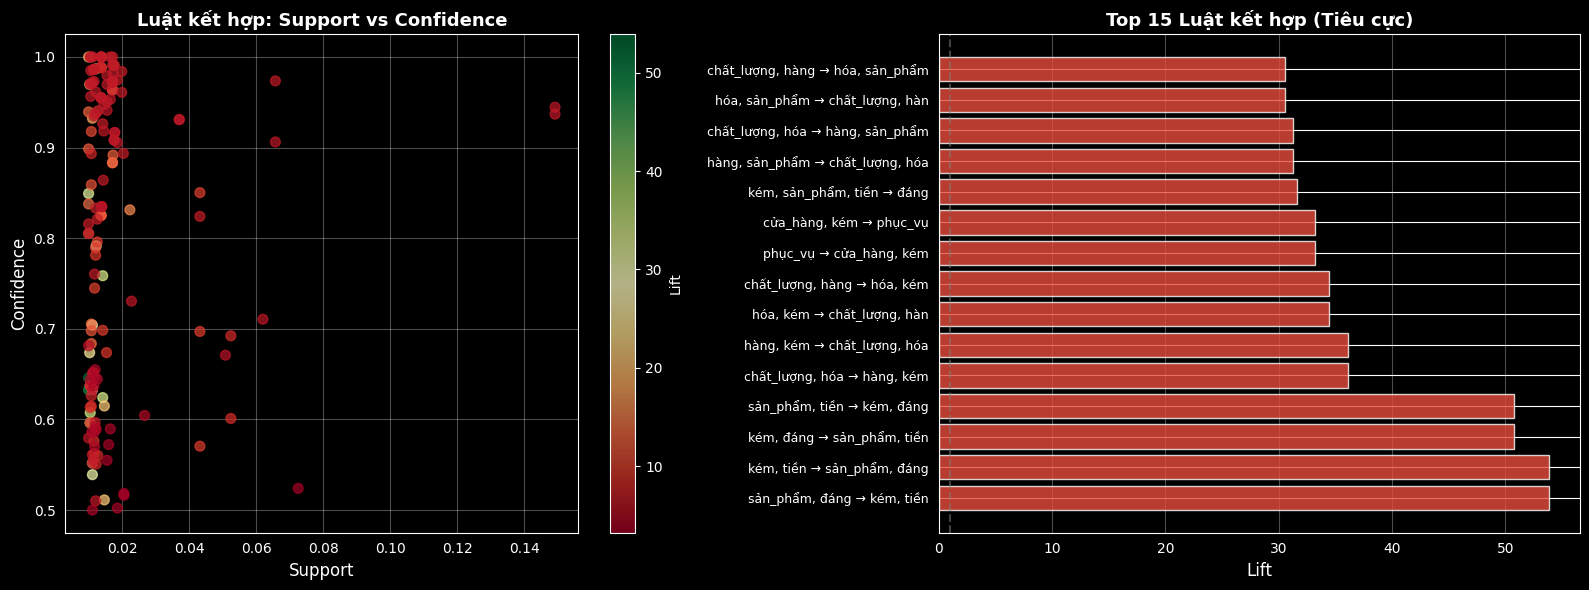

In [8]:
# Visualize top 20 luật — Heatmap Support × Confidence
top_rules = rules.head(20)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter: Support vs Confidence, màu = Lift
sc = axes[0].scatter(
    rules['support'], rules['confidence'],
    c=rules['lift'], cmap='RdYlGn', alpha=0.7, s=50
)
plt.colorbar(sc, ax=axes[0], label='Lift')
axes[0].set_xlabel('Support', fontsize=12)
axes[0].set_ylabel('Confidence', fontsize=12)
axes[0].set_title('Luật kết hợp: Support vs Confidence', fontsize=13, fontweight='bold')
axes[0].grid(alpha=0.3)

# Bar chart top 15 theo lift
rule_labels = [f"{a} → {c}" for a, c in zip(
    top_rules['antecedents_str'].str[:20],
    top_rules['consequents_str'].str[:15]
)][:15]
axes[1].barh(range(len(rule_labels[:15])), top_rules['lift'][:15],
             color='#e74c3c', alpha=0.8)
axes[1].set_yticks(range(len(rule_labels[:15])))
axes[1].set_yticklabels(rule_labels[:15], fontsize=9)
axes[1].set_xlabel('Lift', fontsize=12)
axes[1].set_title('Top 15 Luật kết hợp (Tiêu cực)', fontsize=13, fontweight='bold')
axes[1].axvline(x=1, color='gray', linestyle='--', alpha=0.5)
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'association_rules_viz.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Hệ thống Gợi ý Sản phẩm (Content-based)

In [9]:
# Tải dataset sản phẩm
df_products = pd.read_excel(REC_DIR / 'data.xlsx')
print(f'Products shape: {df_products.shape}')
print(f'Columns: {df_products.columns.tolist()}')
display(df_products.head(3))

Products shape: (3060, 4)
Columns: ['item_id', 'shop_id', 'shop_location', 'name']


,item_id,shop_id,shop_location,name
0,6685849255,65589552,TP. Hồ Chí Minh,[Mã ELBAU1TR giảm 5% ] Điện Thoại Samsung Gala...
1,1236186398,1657913,Hà Nội,"Điện Thoại Nokia 101,Nokia 100, Nokia 105 Zin ..."
2,9764742653,453347243,TP. Hồ Chí Minh,Điện thoại TECNO POVA2 (4GB+64GB) - Hàng chính...


In [10]:
# Tải mô tả sản phẩm từ JSON
with open(REC_DIR / 'shopee_product_desc.json', 'r', encoding='utf-8') as f:
    shopee_desc = json.load(f)

if isinstance(shopee_desc, list):
    df_shopee_desc = pd.DataFrame(shopee_desc)
else:
    df_shopee_desc = pd.DataFrame.from_dict(shopee_desc, orient='index')

print(f'Shopee desc shape: {df_shopee_desc.shape}')
display(df_shopee_desc.head(3))

Shopee desc shape: (13114, 2)


,url,desc
0,https://shopee.vn/Snack-hương-bò-thơm-cay-sườn...,🍒🍒🍒🍒Ngon nhé mọi người tha hồ cho bạn tận hươn...
1,https://shopee.vn/Gạo-lứt-đen-hữu-cơ-100-TÔM-V...,GẠO LỨT ĐEN (GẠO LỨT TÍM THAN) - TÔM VÀNG\n\n...
2,https://shopee.vn/Thanh-Gạo-Lứt-Granola-Mix-Ro...,💟💟💟 THANH GẠO LỨT CHÀ BÔNG MIX HẠT DINH DƯỠNG ...


In [11]:
def build_product_catalog(
    df_products: pd.DataFrame,
    df_desc: pd.DataFrame
) -> pd.DataFrame:
    """
    Xây dựng danh mục sản phẩm chuẩn hóa với các cột:
    - product_id, name, category, description, price, combined_text
    """
    # Tự động nhận diện cột - điều chỉnh theo dataset thực tế
    catalog_records = []

    for idx, row in df_products.iterrows():
        record = {
            'product_id': str(idx),
            'name': str(row.get('name', row.get('product_name', row.iloc[0]))),
            'category': str(row.get('category', row.get('Category', 'Khác'))),
            'price': row.get('price', row.get('Price', 0)),
            'description': str(row.get('description', row.get('Description', ''))),
            'rating': row.get('rating', row.get('Rating', 0)),
        }
        # Kết hợp text để vectorize
        record['combined_text'] = f"{record['name']} {record['category']} {record['description']}"
        catalog_records.append(record)

    return pd.DataFrame(catalog_records)


df_catalog = build_product_catalog(df_products, df_shopee_desc)
print(f'✅ Product catalog: {df_catalog.shape}')
display(df_catalog[['product_id', 'name', 'category', 'price']].head(5))

✅ Product catalog: (3060, 7)


,product_id,name,category,price
0,0,[Mã ELBAU1TR giảm 5% ] Điện Thoại Samsung Gala...,Khác,0
1,1,"Điện Thoại Nokia 101,Nokia 100, Nokia 105 Zin ...",Khác,0
2,2,Điện thoại TECNO POVA2 (4GB+64GB) - Hàng chính...,Khác,0
3,3,Điện Thoại Siêu Dễ Thương Mini BM10 Thay Đổi G...,Khác,0
4,4,[Mã ELBAU1TR giảm 5% ] Điện thoại Samsung Gala...,Khác,0


In [12]:
class ProductRecommender:
    """
    Hệ thống Gợi ý Sản phẩm dựa trên Content-based Filtering.
    Sử dụng TF-IDF + Cosine Similarity.
    """

    def __init__(self, ngram_range=(1, 2), max_features=30_000):
        self.vectorizer = TfidfVectorizer(
            ngram_range=ngram_range,
            max_features=max_features,
            min_df=1,
            sublinear_tf=True,
        )
        self.df_catalog = None
        self.tfidf_matrix = None

    def fit(self, df_catalog: pd.DataFrame, text_column: str = 'combined_text'):
        """Huấn luyện vectorizer trên danh mục sản phẩm."""
        self.df_catalog = df_catalog.reset_index(drop=True)
        self.tfidf_matrix = self.vectorizer.fit_transform(
            df_catalog[text_column].fillna('')
        )
        return self

    def recommend_by_query(
        self,
        query: str,
        top_k: int = 10,
        min_similarity: float = 0.05
    ) -> pd.DataFrame:
        """Gợi ý sản phẩm dựa trên query text."""
        query_vec = self.vectorizer.transform([query])
        similarities = cosine_similarity(query_vec, self.tfidf_matrix).flatten()

        # Lọc theo ngưỡng similarity
        top_idx = np.where(similarities >= min_similarity)[0]
        top_idx = top_idx[np.argsort(similarities[top_idx])[::-1]][:top_k]

        result = self.df_catalog.iloc[top_idx].copy()
        result['similarity_score'] = similarities[top_idx].round(4)
        return result[['product_id', 'name', 'category', 'price',
                       'rating', 'similarity_score']]

    def recommend_similar(
        self,
        product_id: str,
        top_k: int = 10
    ) -> pd.DataFrame:
        """Gợi ý sản phẩm tương tự với sản phẩm đã cho."""
        idx_list = self.df_catalog.index[
            self.df_catalog['product_id'] == product_id
        ].tolist()
        if not idx_list:
            return pd.DataFrame()

        idx = idx_list[0]
        product_vec = self.tfidf_matrix[idx]
        similarities = cosine_similarity(product_vec, self.tfidf_matrix).flatten()
        similarities[idx] = 0  # Loại chính sản phẩm đó

        top_idx = np.argsort(similarities)[::-1][:top_k]
        result = self.df_catalog.iloc[top_idx].copy()
        result['similarity_score'] = similarities[top_idx].round(4)
        return result[['product_id', 'name', 'category', 'price',
                       'rating', 'similarity_score']]


print('✅ Lớp ProductRecommender đã định nghĩa')

✅ Lớp ProductRecommender đã định nghĩa


In [13]:
# Huấn luyện Recommender
recommender = ProductRecommender(ngram_range=(1, 2), max_features=30_000)
recommender.fit(df_catalog, text_column='combined_text')

print(f'✅ Recommender đã huấn luyện xong!')
print(f'   TF-IDF matrix: {recommender.tfidf_matrix.shape}')
print(f'   Số sản phẩm: {len(df_catalog):,}')

✅ Recommender đã huấn luyện xong!
   TF-IDF matrix: (3060, 12231)
   Số sản phẩm: 3,060


In [14]:
# Demo gợi ý
demo_queries = [
    'áo thun cotton thoáng mát',
    'điện thoại pin trâu camera đẹp',
    'kem dưỡng ẩm da mặt',
]

for query in demo_queries:
    print(f'\n🔍 Query: "{query}"')
    recs = recommender.recommend_by_query(query, top_k=5)
    if len(recs) > 0:
        display(recs)
    else:
        print('  Không tìm thấy sản phẩm phù hợp')


🔍 Query: "áo thun cotton thoáng mát"


,product_id,name,category,price,rating,similarity_score
1565,1565,Áo nắng+ áo next xanh comboo,Khác,0,0,0.4612
2493,2493,Áo Phông Game Liên Minh Huyền Thoại Giá Rẻ LOL01,Khác,0,0,0.2655



🔍 Query: "điện thoại pin trâu camera đẹp"


,product_id,name,category,price,rating,similarity_score
1694,1694,"Điện thoại Xiaomi Redmi 6 Pro, 2 sim pin trâu",Khác,0,0,0.2820
2202,2202,điện thoại Samsung Galaxy J7 Pro 2sim ram 3G/3...,Khác,0,0,0.2586
757,757,điện thoại Samsung Galaxy J7 Pro 2sim ram 3G/3...,Khác,0,0,0.2586
146,146,[Siêu Sale] điện thoại Xiaomi Redmi 5 Plus 2s...,Khác,0,0,0.2332
2774,2774,Điện thoại Nokia 1280 chính hãng – CHUẦN - PIN...,Khác,0,0,0.2304



🔍 Query: "kem dưỡng ẩm da mặt"


,product_id,name,category,price,rating,similarity_score
2445,2445,Mặt lưng kính LG V60 thinQ,Khác,0,0,0.2323
2836,2836,Mặt kính Điện thoại Nokia 8800 sirocco,Khác,0,0,0.2297
1617,1617,"Mặt lưng Nokia X7 / Nokia 8.1 chính hãng , bảo...",Khác,0,0,0.2017
1404,1404,Miếng dán Kính Cường Lực Mặt lưng Ip7p/8p/X,Khác,0,0,0.1806
871,871,"Nắp lưng redmi k30 kính 5g, mặt lưng xiaomi re...",Khác,0,0,0.1773


## 5. Lưu kết quả

In [15]:
# Lưu association rules
rules_export = rules[['antecedents_str', 'consequents_str',
                       'support', 'confidence', 'lift']].copy()
rules_export.to_csv(MODELS_DIR / 'association_rules.csv',
                    index=False, encoding='utf-8-sig')
joblib.dump(rules_export, MODELS_DIR / 'association_rules.pkl')

# Lưu Recommender
joblib.dump(recommender, MODELS_DIR / 'recommender.pkl')

# Lưu catalog chuẩn hóa
df_catalog.to_csv(MODELS_DIR / 'product_catalog.csv',
                  index=False, encoding='utf-8-sig')

print('✅ Phase 4 hoàn thành! Các file đã lưu:')
print('  - datas/models/association_rules.pkl / .csv')
print('  - datas/models/recommender.pkl')
print('  - datas/models/product_catalog.csv')
print('\n📌 Tiếp theo: Chạy src/api/main.py để khởi động API server')

✅ Phase 4 hoàn thành! Các file đã lưu:
  - datas/models/association_rules.pkl / .csv
  - datas/models/recommender.pkl
  - datas/models/product_catalog.csv

📌 Tiếp theo: Chạy src/api/main.py để khởi động API server
